In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")

INITIAL_FEATURES_PATH = PROJECT_ROOT / 'data' / 'normal_features'
INITIAL_TRAIN_PATH = INITIAL_FEATURES_PATH / 'train.parquet'
INITIAL_VAL_PATH = INITIAL_FEATURES_PATH / 'val.parquet'
INITIAL_TEST_PATH = INITIAL_FEATURES_PATH / 'test.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Using device: cuda


# KNN Model - on initial features
By leveraging initial metadata-derived features, this notebook treats citation prediction as a supervised binary classification task.

To ensure code quality and reusability, we use the shared model hierarchy:

- `BaseModel`: an abstract class that defines the common contract for preprocessing, training, prediction, evaluation, and saving.
- `KNNModel`: the concrete KNN implementation. It drops non-feature columns, applies `RobustScaler` using training statistics, and reuses the fitted scaler for validation and test data.


## 1. Load initial feature data

In [ ]:
# splitting
df_train = pd.read_parquet(INITIAL_TRAIN_PATH)
df_val = pd.read_parquet(INITIAL_VAL_PATH)
df_test = pd.read_parquet(INITIAL_TEST_PATH)

ID_COLUMNS = ["article_id", "ref_id"]
df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})

NameError: name 'TRAIN_PATH' is not defined

## 2. Baseline model

[KNN_baseline] Preprocessing 2162534 rows...
Label distribution:
is_reference_valid
0    0.500003
1    0.499997
Name: proportion, dtype: float64
[KNN_baseline] Starting training...
Selected 10812/2162534
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      5283
           1     1.0000    1.0000    1.0000      5529

    accuracy                         1.0000     10812
   macro avg     1.0000    1.0000    1.0000     10812
weighted avg     1.0000    1.0000    1.0000     10812



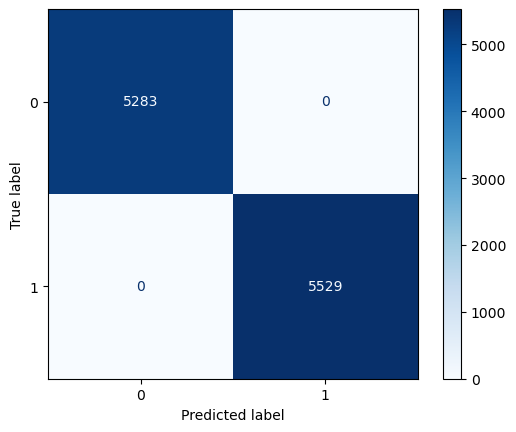

In [ ]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski')
KNN_baseline.train_pipeline(df_train, random_state=RANDOM_STATE, frac=0.005)

> The confusion matrix for the training set shows an accuracy of 100%. This indicates severe overfitting, most probably because the number of neighbors is set to 5, that is relatively small and it's evaluated on the same data it stored, ending in just memorizing the training set instead of generalize the predictions.

[KNN_baseline] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
1    0.5061
0    0.4939
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.9172    0.8184    0.8650      4939
           1     0.8396    0.9279    0.8815      5061

    accuracy                         0.8738     10000
   macro avg     0.8784    0.8731    0.8733     10000
weighted avg     0.8779    0.8738    0.8734     10000



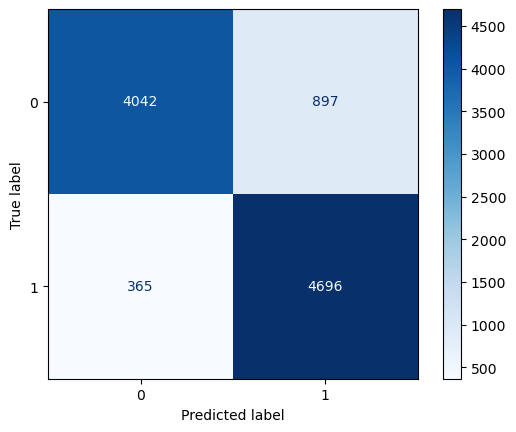

In [ ]:
KNN_baseline.test_pipeline(df_test.sample(10000))

> The baseline run is used as a quick sanity check before hyperparameter tuning. Final results should be interpreted from the tuned model evaluation below.


## 3. Hyperparameter tuning
KNN can be computationally expensive on large initial-feature matrices. To keep tuning feasible, `GridSearchCV` is run on a representative subset of the train and validation data.

The notebook uses `PredefinedSplit` instead of standard K-fold cross-validation. This keeps the validation fold aligned with the project split and avoids leakage from the training set.


In [ ]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [ ]:
# tuning
KNN_initial = KNNModel("KNN_initial")
KNN_initial.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=N_JOBS)

[KNN_initial] Grid Search...
[KNN_initial] Preprocessing 2162534 rows...
Label distribution:
is_reference_valid
0    0.500003
1    0.499997
Name: proportion, dtype: float64
[KNN_initial] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64

Starting tuning on 50000 samples...

Best parameters found:
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}

Optimal model ready: KNeighborsClassifier(metric='manhattan', n_jobs=-1, n_neighbors=15,
                     weights='distance')
[KNN_initial] Train model with best params...
[KNN_initial] Preprocessing 2162534 rows...
Label distribution:
is_reference_valid
0    0.500003
1    0.499997
Name: proportion, dtype: float64
[KNN_initial] Starting training...
Selected 21625/2162534


## 4. Final model with best parameters
Once the optimal number of neighbors, distance metric, and weighting strategy are selected, the model is retrained on the full training split.

Performance is assessed using:
- Weighted F1-score, to summarize class-balanced performance.
- Confusion matrix, to visualize false positives and false negatives.
- Classification report, with precision, recall, F1-score, and accuracy.


[KNN_initial] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
1    0.5003
0    0.4997
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.5586    0.6452    0.5988      4997
           1     0.5807    0.4907    0.5319      5003

    accuracy                         0.5679     10000
   macro avg     0.5696    0.5679    0.5653     10000
weighted avg     0.5696    0.5679    0.5653     10000



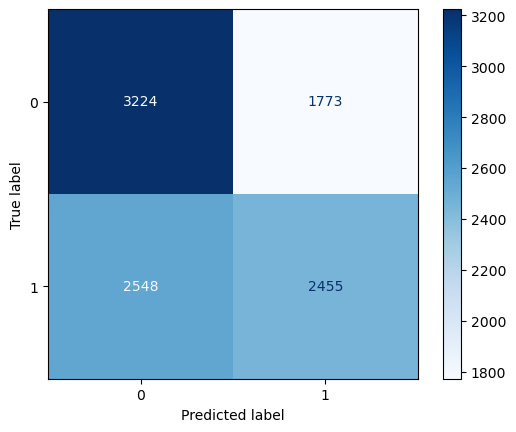

In [ ]:
KNN_initial.test_pipeline(df_test.sample(10000))

> After performing a Grid Search, the optimal number of neighbors increased to 15 using the Euclidean metric. This hypertuned model achieved a test accuracy of 56.79%, a slightly increase in performance respect to the baseline, but still the model keep confronting the problem of overfitting as showed in the hypertuned model for the train set.

## 5. Save the pretrained model
Finally, the trained model is saved with the custom `save_model_artifact` utility, so it can be reused for later evaluation, explainability, or deployment experiments.


In [ ]:
from utils.model_saver import save_model_artifact
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

save_model_artifact(KNN_initial, df_name='initial_features', 
                    model_name="Best_KNN_initial_based", 
                    relative_model_dir=MODEL_SAVE_PATH)